# Exercise 8: Unsupervised Learning


```{admonition} Run or download this notebook
:class: how-to-use

This page is fully readable as it is, and the interactive activities work
here in the browser. To **run or change the Python code**, use the portable
version of the notebook:

- **[Open the portable notebook in Colab](https://colab.research.google.com/github/yoavmp/ml-neuro-tutorials/blob/main/book/downloads/chapter_08/exercise_08_portable.ipynb)**
- **[View or download the portable `.ipynb`](https://raw.githubusercontent.com/yoavmp/ml-neuro-tutorials/main/book/downloads/chapter_08/exercise_08_portable.ipynb)**
  for VS Code or Jupyter

The portable notebook keeps every Python analysis cell and swaps each
embedded activity for a link back to this page.
```


## What this notebook covers

This is Exercise 8 of *Machine Learning for Neuroscience*. Every earlier
exercise predicted a target from labeled examples. This notebook asks a
different question: what can we learn from brain measurements when no
target is supplied at all?

In this notebook you will:

1. reduce many brain measurements to a smaller set of principal components;
2. examine what those components represent;
3. group participants with K-means without using a target label;
4. use PCA correctly inside a supervised prediction pipeline.

**Prerequisites:** Exercise 2 (regression) and Exercise 6 or 7 (any
tree-based exercise, for held-out validation habits).


## 1. Learning Without a Target

Every earlier exercise was **supervised**: each participant had a target
value (age, diagnosis) that the model learned to predict, and we judged
success by held-out prediction accuracy. **Unsupervised** methods receive
only the input measurements -- no target column -- and instead describe
structure that already exists in the data.

Unsupervised methods can help researchers:

- summarize many related measurements with a much smaller set of numbers;
- visualize participants in a lower-dimensional space;
- explore whether participants with similar measurement profiles form
  groups;
- generate hypotheses for later validation on independent data.

Nothing here replaces held-out testing. An unsupervised result is a
starting point for a hypothesis, not a confirmed finding.


```{admonition} Think first
:class: think-first
With no target column supplied, what information can an unsupervised
algorithm actually use to group or summarize participants?
```


In [1]:
# Data loading. In the published book this cell is collapsed; it is plain,
# runnable Python -- one public CSV pinned to an immutable commit. This is
# the exact same ABIDE-II table Exercises 2, 4, 5, 6, and 7 use.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold

PIN = "e4eed3c4daa7f40b0ba931182a8c7e5e691dba6b"
BASE = f"https://raw.githubusercontent.com/neurohackademy/nh2020-curriculum/{PIN}/tu-machine-learning-yarkoni/data"

model_df = pd.read_csv(f"{BASE}/abide2.tsv", sep="\t")
model_df = model_df.loc[:, [c for c in model_df.columns if not str(c).startswith("Unnamed")]]

BRAIN_COLS = [c for c in model_df.columns if c.startswith("fs")]
FEATURES = [c for c in BRAIN_COLS if c.startswith("fsCT_")]
assert all(c.startswith("fsCT_") for c in FEATURES)
assert "age" not in FEATURES

print(f"data table: {model_df.shape[0]} participants x {model_df.shape[1]} columns")
print(f"{len(FEATURES)} cortical-thickness predictors")


data table: 1004 participants x 1446 columns
360 cortical-thickness predictors


## 2. PCA: Representing Many Features with Fewer Dimensions

Principal component analysis (PCA) builds new axes -- **principal
components** -- as combinations of the original features:

- **PC1** captures the greatest available variance in the data;
- **PC2** captures the greatest *remaining* variance, subject to being
  orthogonal (at a right angle) to PC1;
- each further component continues the same pattern, always orthogonal to
  every earlier one.

Every participant gets a **score** on each component -- its coordinate
along that new axis. Every original feature gets a **loading** on each
component -- how strongly, and in which direction, that feature contributes
to it. The **explained variance** of a component is the share of the total
variability in the data it captures; keeping only the first few components
means some information is discarded, and the **reconstruction loss** is a
direct measure of how much.

**PCA is dimensionality reduction and feature extraction, not feature
selection.** It never keeps a subset of the original measurements as-is --
every component is a new combination of all of them. We will not derive
the underlying matrix algebra here; the activity below builds the same
intuition visually.


## 3. Interactive Activity -- Find the Best Projection

The activity below uses a small, **simulated** two-dimensional dataset with
a clear but imperfect correlation between its two variables -- these are not
brain measurements. Choose a projection angle with the slider and watch how
much variance that axis captures and how much reconstruction error is left
behind; predict the best angle before revealing the true first principal
component.


<iframe
  title="Interactive projection-angle activity for a small simulated two-dimensional dataset"
  src="../../_static/widgets/app/index.html?config=../configs/pca_projection.json"
  loading="lazy"
  width="100%"
  height="1400"
  class="ml-activity"
  style="width: 100%;"
></iframe>


In [2]:
# Optional: a compact Python reproduction of the activity's math, using the
# exact same fixed distribution and seed as the widget's own committed data
# artifact. The projection at any angle is closed-form trigonometry -- no
# model is fit.
PROJ_SEED = 11
PROJ_N = 40
SIGMA_X, SIGMA_Y, RHO = 3.0, 2.0, 0.75

rng = np.random.RandomState(PROJ_SEED)
cov = [[SIGMA_X**2, RHO * SIGMA_X * SIGMA_Y], [RHO * SIGMA_X * SIGMA_Y, SIGMA_Y**2]]
pts = rng.multivariate_normal([0.0, 0.0], cov, size=PROJ_N)
pts = pts - pts.mean(axis=0)

demo_angle_deg = 30.0
theta = np.radians(demo_angle_deg)
u = np.array([np.cos(theta), np.sin(theta)])
projected = pts @ u
total_variance = float(np.mean(pts[:, 0] ** 2) + np.mean(pts[:, 1] ** 2))
captured = float(np.mean(projected ** 2))
print(f"angle = {demo_angle_deg:.0f} deg   captured variance = {captured:.2f}   "
      f"reconstruction MSE = {total_variance - captured:.2f}   (of {total_variance:.2f} total)")


angle = 30 deg   captured variance = 9.26   reconstruction MSE = 1.23   (of 10.48 total)


## 4. PCA with ABIDE-II Neuroimaging Data

Now we apply PCA to the real cortical-thickness table: the same 1004
participants and 360 regions used throughout this course. We standardize
every feature first, even though all 360 are the same measurement type
(cortical thickness in millimeters): some regions are naturally thicker and
more variable than others, and without standardization PCA would be
dominated by whichever regions happen to have the largest raw variance
rather than by genuine shared patterns of thickness.


In [3]:
Xs = StandardScaler().fit_transform(model_df[FEATURES].to_numpy(float))
pca = PCA(n_components=50, random_state=0).fit(Xs)
scores = pca.transform(Xs)
evr = pca.explained_variance_ratio_
cumvar = np.cumsum(evr)

print(f"PCA fit on {Xs.shape[0]} participants x {Xs.shape[1]} standardized features")
print(f"PC1 explained variance = {evr[0]:.1%}   PC2 explained variance = {evr[1]:.1%}")
for k in [2, 5, 10, 20, 50]:
    print(f"cumulative explained variance through PC{k} = {cumvar[k - 1]:.1%}")


PCA fit on 1004 participants x 360 standardized features
PC1 explained variance = 36.1%   PC2 explained variance = 5.9%
cumulative explained variance through PC2 = 42.0%
cumulative explained variance through PC5 = 49.4%
cumulative explained variance through PC10 = 54.3%
cumulative explained variance through PC20 = 60.1%
cumulative explained variance through PC50 = 70.2%


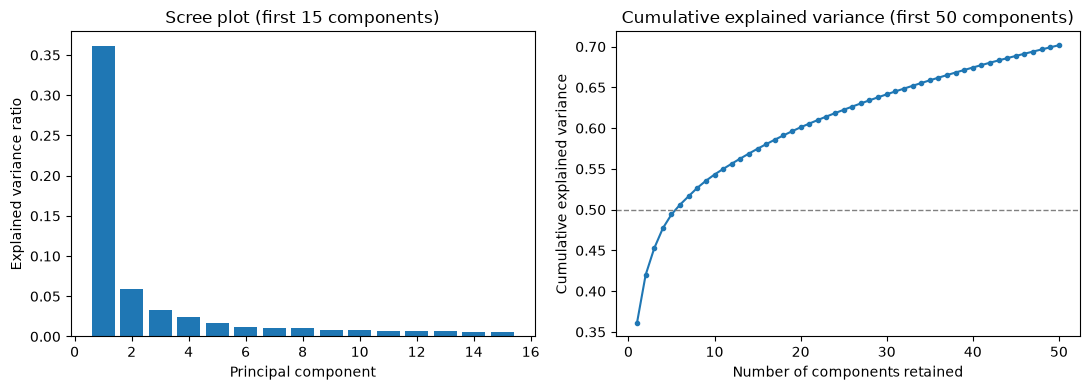

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
n_show = 15
axes[0].bar(range(1, n_show + 1), evr[:n_show])
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree plot (first 15 components)")

axes[1].plot(range(1, 51), cumvar, marker=".")
axes[1].axhline(0.5, color="0.5", ls="--", lw=1)
axes[1].set_xlabel("Number of components retained")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative explained variance (first 50 components)")
plt.tight_layout()
plt.show()


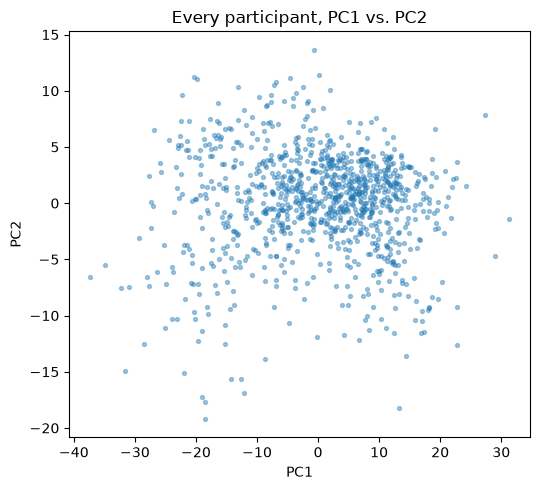

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(scores[:, 0], scores[:, 1], s=8, alpha=0.4)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Every participant, PC1 vs. PC2")
plt.tight_layout()
plt.show()


### Interpreting the components

The bars below show the individual regions with the strongest (positive or
negative) loading on PC1 and PC2 -- the *direction* of each region's
contribution is preserved here, unlike the grouped summary further down.


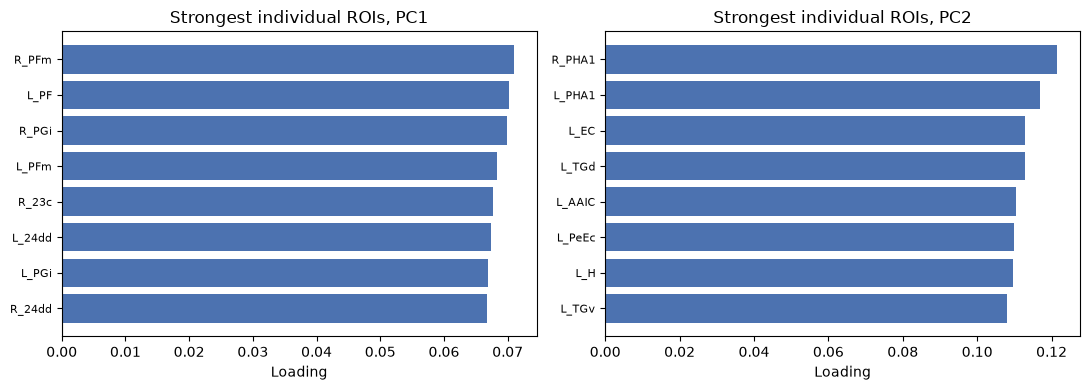

PC1 loadings: 100% positive (a uniform, whole-cortex pattern)


In [6]:
loadings = pca.components_  # (50, 360)
N_TOP = 8

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i, ax in enumerate(axes):
    order = np.argsort(-np.abs(loadings[i]))[:N_TOP]
    labels = [FEATURES[j].replace("fsCT_", "").replace("_ROI", "") for j in order]
    values = loadings[i][order]
    colors = ["#4c72b0" if v > 0 else "#c44e52" for v in values]
    ax.barh(range(N_TOP), values[::-1], color=colors[::-1])
    ax.set_yticks(range(N_TOP))
    ax.set_yticklabels(labels[::-1], fontsize=8)
    ax.set_xlabel("Loading")
    ax.set_title(f"Strongest individual ROIs, PC{i + 1}")
    ax.axvline(0, color="0.6", lw=0.8)
plt.tight_layout()
plt.show()

print(f"PC1 loadings: {int(np.all(loadings[0] > 0)) * 100}% positive "
      "(a uniform, whole-cortex pattern)" if np.all(loadings[0] > 0) or np.all(loadings[0] < 0)
      else "PC1 loadings are mixed in sign")


The grouped view below summarizes loading **magnitude** within familiar
anatomical groups -- frontal, parietal, temporal, and occipital, using the
same bundle definitions as Exercise 5's feature-selection activity. We
compute the **mean absolute loading** within each group, never a signed
sum: positive and negative loadings within the same group would otherwise
cancel and hide real structure.


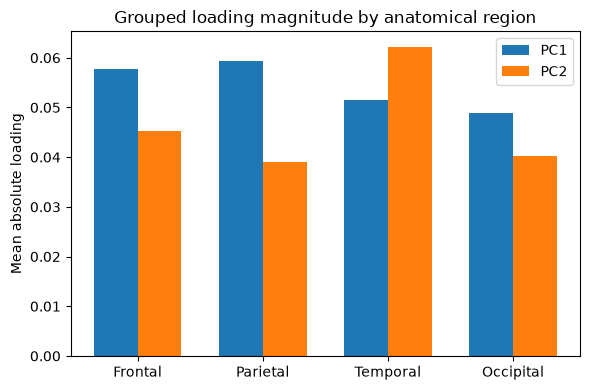

frontal    PC1=0.0577  PC2=0.0453
parietal   PC1=0.0594  PC2=0.0390
temporal   PC1=0.0516  PC2=0.0622
occipital  PC1=0.0489  PC2=0.0402


In [7]:
# Same anatomical bundle ROI lists Exercise 5's feature-selection activity
# uses (book/config/abide_modeling.json bundles.{frontal,parietal,temporal,
# occipital}), inlined here -- like Exercise 5 -- rather than imported from
# the repository, so this cell stays runnable in the portable notebook.
ANATOMICAL_ROIS = {
    "frontal": [
        "46", "9-46d", "a9-46v", "p9-46v", "9a", "9p", "8C", "8Av", "8Ad",
        "IFJa", "IFJp", "IFSa", "IFSp", "p47r", "a47r", "8BL", "a32pr",
        "p32pr", "d32", "8BM", "SCEF",
    ],
    "parietal": [
        "PGs", "PGi", "PGp", "PFm", "PF", "PFt", "PFop", "IP0", "IP1", "IP2",
        "IPS1", "LIPv", "LIPd", "MIP", "VIP", "AIP", "7PC", "7PL", "7Pm",
        "7AL", "7Am",
    ],
    "temporal": [
        "STGa", "STSda", "STSdp", "STSva", "STSvp", "TE1a", "TE1m", "TE1p",
        "TE2a", "TE2p", "TGd", "TGv", "TF", "PHT", "TA2", "A5", "STV", "PSL",
    ],
    "occipital": [
        "V1", "V2", "V3", "V4", "V3A", "V3B", "V6", "V6A", "V7", "V8", "VVC",
        "VMV1", "VMV2", "VMV3", "LO1", "LO2", "LO3", "PIT", "FST", "V4t",
        "V3CD", "DVT", "ProS",
    ],
}

ANATOMICAL_GROUPS = list(ANATOMICAL_ROIS)
group_mean_abs_loading = {}
for group in ANATOMICAL_GROUPS:
    cols = [f"fsCT_{hemi}_{roi}_ROI" for roi in ANATOMICAL_ROIS[group] for hemi in ("L", "R")]
    assert all(c in FEATURES for c in cols)
    idx = [FEATURES.index(c) for c in cols]
    group_mean_abs_loading[group] = [float(np.mean(np.abs(loadings[pc][idx]))) for pc in range(2)]

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(ANATOMICAL_GROUPS))
width = 0.35
pc1_vals = [group_mean_abs_loading[g][0] for g in ANATOMICAL_GROUPS]
pc2_vals = [group_mean_abs_loading[g][1] for g in ANATOMICAL_GROUPS]
ax.bar(x - width / 2, pc1_vals, width, label="PC1")
ax.bar(x + width / 2, pc2_vals, width, label="PC2")
ax.set_xticks(x)
ax.set_xticklabels([g.capitalize() for g in ANATOMICAL_GROUPS])
ax.set_ylabel("Mean absolute loading")
ax.set_title("Grouped loading magnitude by anatomical region")
ax.legend()
plt.tight_layout()
plt.show()
for group in ANATOMICAL_GROUPS:
    print(f"{group:10s} PC1={group_mean_abs_loading[group][0]:.4f}  PC2={group_mean_abs_loading[group][1]:.4f}")


A few questions worth sitting with before moving on:

- Does PC1 describe a global cortical-thickness pattern, or a more regional
  one? Look back at the sign of its loadings.
- Can a component with less explained variance than PC1 still be
  scientifically useful?
- What information is hidden when 360 dimensions are shown using only PC1
  and PC2?


## 5. Clustering and K-Means

**Clustering** groups observations so that members of the same group are
more similar to each other than to members of other groups -- without using
any target label. **K-means** is the only clustering method covered in this
notebook. It repeats four steps:

1. initialize `k` cluster centers;
2. assign each participant to its nearest center;
3. update each center to the mean of the participants currently assigned to
   it;
4. repeat steps 2-3 until assignments stop changing or a stopping rule is
   reached.

K-means finds a partition that minimizes the sum of squared distances from
each participant to its assigned center -- it does not discover a
guaranteed biological truth. A visible group of points in a PC1-PC2 plot is
not automatically a clinical subtype.

**Choosing `k`.** Three considerations, together, guide the choice:

- **inertia and the elbow**: inertia (the quantity K-means minimizes)
  always decreases as `k` grows; look for where adding another cluster
  stops helping much;
- **silhouette score**: how well-separated the clusters are, on a scale
  from -1 to 1;
- **scientific usability**: whether the resulting cluster sizes and any
  interpretation are actually useful for the question being asked.

There is often no single objectively correct `k`. A higher silhouette score
alone does not establish a biological subtype -- it only describes how
cleanly the *chosen* features separate into groups.


## 6. Research Example -- Exploring Neuroanatomical Profiles

Neuroimaging research has used PCA followed by clustering as an
**exploratory** step: summarize many structural measurements with a handful
of components, group participants in that reduced space, and only *then*
compare the resulting groups against external characteristics such as
diagnosis. This generates hypotheses about possible subgroups; it does not,
by itself, confirm that they exist as a distinct biological category --
that requires independent validation this notebook does not attempt.

The workflow, in order:

1. standardize the cortical-thickness features;
2. fit PCA without using diagnosis or any other target;
3. retain a chosen number of components;
4. fit K-means in that retained component space;
5. only then compare the resulting clusters with external participant
   characteristics.

Diagnosis, sex, site, and age never enter steps 1-4.


In [8]:
# Step 1-2 (already fit above): Xs, pca, scores.
# Step 3: retain 10 components.
RETAINED_PC = 10
RESEARCH_K = 3
demo_scores = scores[:, :RETAINED_PC]

# Step 4: fit K-means -- explicit n_init and random_state, as required for
# every K-means fit in this notebook.
demo_kmeans = KMeans(n_clusters=RESEARCH_K, n_init=10, random_state=0).fit(demo_scores)
demo_labels = demo_kmeans.labels_
demo_sizes = np.bincount(demo_labels)
demo_silhouette = silhouette_score(demo_scores, demo_labels)

print(f"retained components = {RETAINED_PC}   k = {RESEARCH_K}")
print(f"cluster sizes: {dict(enumerate(demo_sizes.tolist()))}")
print(f"silhouette score = {demo_silhouette:.3f}")

# Step 5: only now compare with an external characteristic (diagnosis).
demo_group = model_df["group"].to_numpy()
for c in range(RESEARCH_K):
    in_cluster = demo_group[demo_labels == c]
    autism_share = float(np.mean(in_cluster == 1))
    print(f"cluster {c}: n={len(in_cluster)}  autism share={autism_share:.2f}")


retained components = 10   k = 3
cluster sizes: {0: 397, 1: 412, 2: 195}
silhouette score = 0.265
cluster 0: n=397  autism share=0.45
cluster 1: n=412  autism share=0.45
cluster 2: n=195  autism share=0.51


```{admonition} Cluster labels are arbitrary
:class: think-first
Cluster labels 0, 1, and 2 above carry no inherent order or meaning -- a
different run could label the same groups 2, 0, 1. Even if the clusters
differ somewhat in their diagnosis proportions, that alone does not make
them autism subtypes: confirming a genuine subtype would require
independent replication and clinical validation this exploratory analysis
does not attempt.
```


## 7. Interactive Activity -- Explore PCA and K-Means

The activity below combines everything in this section into one explorer.
Choose how many principal components to retain, a number of clusters `k`,
and an initialization seed; then pick an external characteristic to inspect
*after* clustering. Clustering always uses every retained component you
select, even though the scatter plot shows only PC1 and PC2.


<iframe
  title="Interactive PCA and K-means explorer for ABIDE-II participants"
  src="../../_static/widgets/app/index.html?config=../configs/pca_kmeans_explorer.json"
  loading="lazy"
  width="100%"
  height="1900"
  class="ml-activity"
  style="width: 100%;"
></iframe>


## 8. Using PCA Before a Model We Already Know

K-nearest neighbours predicts a participant's age from the ages of the
training participants whose cortical-thickness profiles are closest to
theirs -- literally, the Euclidean distance between two participants' 360
brain measurements. In a space with hundreds of dimensions, many directions
carry little information about age, and those directions still count in
every distance calculation, making "closest" less informative than it would
be in a smaller, more relevant space.

PCA can replace the 360 original cortical-thickness features with a smaller
set of component scores before KNN ever calculates a distance:

```python
Pipeline([
    ("scale", StandardScaler()),
    ("pca", PCA()),
    ("model", KNeighborsRegressor()),
])
```

PCA here is still **feature extraction, not feature selection** -- every
retained component is a combination of all 360 original measurements, not a
subset of them. The number of retained components and `k` are both model
parameters: we choose them the same way we choose any other model
parameter, using cross-validation on the development partition only, with
`StandardScaler` and `PCA` refit inside every fold. PCA is not guaranteed to
help KNN -- it keeps the directions that explain the most variation in the
cortical-thickness features themselves, which were never chosen with age in
mind.

In [9]:
has_age = model_df["age"].notna()
X = model_df.loc[has_age, FEATURES].to_numpy(float)
y = model_df.loc[has_age, "age"].to_numpy(float)
groups = model_df.loc[has_age, "group"].to_numpy()

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups, test_size=0.25, random_state=42, stratify=groups
)
print(f"n_train (development) = {len(y_train)}   n_test = {len(y_test)} (locked; read once, below)")


n_train (development) = 753   n_test = 251 (locked; read once, below)


Candidate component counts: `[5, 10, 20, 50, 100]`; candidate `k` values:
`[5, 10, 20, 40]`. Every (components, `k`) combination is scored by 5-fold
cross-validation restricted to the development partition -- `StandardScaler`
and `PCA` are refit inside every fold, never once on the full development
set before splitting, so no fold's validation rows can leak into its own
preprocessing. The identical `k` grid, evaluated under the identical folds,
also selects a standardized KNN model on the original 360 features (no PCA
step), for a fair comparison.

In [10]:
component_grid = [5, 10, 20, 50, 100]
k_grid = [5, 10, 20, 40]
cv = KFold(n_splits=5, shuffle=True, random_state=13)
fold_splits = list(cv.split(X_train))

pca_knn_rows = []
for n in component_grid:
    for k in k_grid:
        fold_mse = []
        for train_idx, val_idx in fold_splits:
            pipe = Pipeline([
                ("scale", StandardScaler()),
                ("pca", PCA(n_components=n, random_state=0)),
                ("model", KNeighborsRegressor(n_neighbors=k)),
            ])
            pipe.fit(X_train[train_idx], y_train[train_idx])
            pred = pipe.predict(X_train[val_idx])
            fold_mse.append(mean_squared_error(y_train[val_idx], pred))
        pca_knn_rows.append({"n_components": n, "k": k, "mean_cv_mse": float(np.mean(fold_mse))})

pca_knn_cv_df = pd.DataFrame(pca_knn_rows)
best_pca_knn = pca_knn_cv_df.loc[pca_knn_cv_df["mean_cv_mse"].idxmin()]
selected_n, selected_k = int(best_pca_knn["n_components"]), int(best_pca_knn["k"])

raw_knn_rows = []
for k in k_grid:
    fold_mse = []
    for train_idx, val_idx in fold_splits:
        pipe = Pipeline([
            ("scale", StandardScaler()),
            ("model", KNeighborsRegressor(n_neighbors=k)),
        ])
        pipe.fit(X_train[train_idx], y_train[train_idx])
        pred = pipe.predict(X_train[val_idx])
        fold_mse.append(mean_squared_error(y_train[val_idx], pred))
    raw_knn_rows.append({"k": k, "mean_cv_mse": float(np.mean(fold_mse))})

raw_knn_cv_df = pd.DataFrame(raw_knn_rows)
best_raw_knn = raw_knn_cv_df.loc[raw_knn_cv_df["mean_cv_mse"].idxmin()]
selected_raw_k = int(best_raw_knn["k"])

pca_knn_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=selected_n, random_state=0)),
    ("model", KNeighborsRegressor(n_neighbors=selected_k)),
]).fit(X_train, y_train)
pca_knn_test_pred = pca_knn_pipe.predict(X_test)
pca_knn_test_mse = mean_squared_error(y_test, pca_knn_test_pred)
pca_knn_test_r2 = r2_score(y_test, pca_knn_test_pred)

raw_knn_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=selected_raw_k)),
]).fit(X_train, y_train)
raw_knn_test_pred = raw_knn_pipe.predict(X_test)
raw_knn_test_mse = mean_squared_error(y_test, raw_knn_test_pred)
raw_knn_test_r2 = r2_score(y_test, raw_knn_test_pred)

results_df = pd.DataFrame([
    {"model": f"PCA({selected_n}) + KNN(k={selected_k})", "test_MSE": pca_knn_test_mse, "test_R2": pca_knn_test_r2},
    {"model": f"KNN(k={selected_raw_k}), 360 raw features", "test_MSE": raw_knn_test_mse, "test_R2": raw_knn_test_r2},
])

In [11]:
print("cross-validation results (development partition only), best 5 of "
      f"{len(pca_knn_cv_df)} (n_components, k) combinations:")
display(pca_knn_cv_df.sort_values("mean_cv_mse").head(5).reset_index(drop=True).round(2))
print(f"\nselected: n_components={selected_n}, k={selected_k}  "
      f"(mean CV MSE = {best_pca_knn['mean_cv_mse']:.1f})")
print(f"raw-feature KNN selected: k={selected_raw_k}  "
      f"(mean CV MSE = {best_raw_knn['mean_cv_mse']:.1f})")
print()
display(results_df.round(3))

cross-validation results (development partition only), best 5 of 20 (n_components, k) combinations:


,n_components,k,mean_cv_mse
0,20,10,24.83
1,20,5,25.06
2,10,10,25.41
3,10,5,26.10
4,10,20,27.11



selected: n_components=20, k=10  (mean CV MSE = 24.8)
raw-feature KNN selected: k=5  (mean CV MSE = 35.4)



,model,test_MSE,test_R2
0,PCA(20) + KNN(k=10),21.049,0.775
1,"KNN(k=5), 360 raw features",32.045,0.657


On this cohort and split, PCA improves KNN: PCA(20) + KNN(k=10) reaches
locked-test MSE=21.0 (R2=+0.775), compared with MSE=32.0 (R2=+0.657) for
standardized KNN on the original 360 features. This is reported here as the
observed result for this dataset, not a guarantee -- PCA keeps the
directions of greatest variation in the cortical-thickness features, which
were never chosen using age, so a dataset whose informative direction sits
at lower variance could see PCA discard exactly the direction KNN needed.

A few things worth remembering from this section:

- Fitting `StandardScaler` and `PCA` before splitting into cross-validation
  folds leaks information about validation rows into preprocessing, even
  though PCA never sees the target `y`.
- PCA remains feature extraction: the retained components are still
  combinations of all 360 original measurements, never a subset of them.
- Reducing dimensionality before computing distances is a different reason
  to use PCA than reducing dimensionality before fitting a linear
  coefficient -- the two models are affected differently by the same
  irrelevant directions.

```{admonition} Think first
:class: think-first
Why might PCA help KNN more directly than it helps a model that does not
calculate distances between participants?
```

## 9. What Should We Remember?

- PCA creates lower-dimensional combinations of the original features --
  never a subset of the original measurements.
- Loadings help interpret what a component represents; grouped magnitude
  summaries use absolute values so opposite-signed regions cannot cancel.
- K-means groups similar observations but does not prove natural or
  biological categories.
- `k` is judged using quantitative evidence (inertia, silhouette) *and*
  scientific usefulness -- not one universal rule.
- In supervised work, preprocessing and PCA must be fitted inside the
  validation pipeline, never before it.

### Questions to take away

1. What is the difference between feature extraction and feature selection?
2. Why must PC2 be orthogonal to PC1?
3. What does a K-means cluster center represent geometrically?
4. Why is mean absolute loading used instead of a signed sum when
   summarizing a group of regions?
5. Could two different, equally reasonable choices of `k` both be
   defensible for the same dataset?
6. Why does fitting PCA outside a cross-validation loop leak information,
   even though PCA does not use the target?
